# Responsible AI: Face Recognition
### Building a gender-neutral, race-agnostic age classifier for Alcohol Purchase Check

---

## Project Context
- **Problem:** Retail analytics systems need age estimation to understand customer demographics
- **Why Responsible AI:** Face images are highly sensitive personal data; systems trained on biased data produce biased outcomes
- **Who is affected:** Any person walking past a retail camera
- **Our Goal:** Build an age classifier whose performance is fair across all races and genders

## Design Decisions (fixed from Day 1)
- Race and gender are **never** used as model inputs
- Race and gender are kept **only** for fairness auditing after training
- No faces are stored — only age-group predictions are output
- System is for **academic research only** — not cleared for deployment

## Datasets & Roles

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy testing | Only dataset with continuous age labels plus race and gender |


## Licenses & Citations (verified)

**UTKFace** — Non-commercial research use only (official page confirmed).
Zhang, Z., Song, Y., & Qi, H. (2017). *Age Progression/Regression by Conditional
Adversarial Autoencoder.* CVPR 2017.


##  Recovery Cell — run this first after any server restart
Reinstalls packages and reloads the saved model and data splits if they exist.
Skip straight to the fairness section if the checkpoint loads successfully.

In [1]:
import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [8]:
from pathlib import Path

BASE = Path("/home/jovyan/vault/data")
BASE.mkdir(parents=True, exist_ok=True)
WORK_DIR = BASE
UTK_DIR  = BASE / "UTKFace" / "UTKFace"

DATA_ALREADY_PRESENT = UTK_DIR.exists()   # <-- add this line

print("BASE:", BASE, "| data present:", DATA_ALREADY_PRESENT)

BASE: /home/jovyan/vault/data | data present: True


In [3]:
# Reinstall packages after a kernel/server restart
import subprocess
for pkg in ["tensorflow", "kaggle"]:
    subprocess.run(["pip", "install", pkg, "-q"])

import os
import pandas as pd

MODEL_PATH = BASE / "age_classifier_baseline.keras"

if MODEL_PATH.exists():
    from tensorflow.keras.models import load_model
    model    = load_model(MODEL_PATH)
    train_df = pd.read_csv(BASE / "train_df.csv")
    val_df   = pd.read_csv(BASE / "val_df.csv")
    test_df  = pd.read_csv(BASE / "test_df.csv")
    print("Checkpoint loaded — model and splits restored")
else:
    print("No checkpoint found — run the notebook from the top")

I0000 00:00:1784967293.212937     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784967293.213893     385 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784967293.255510     385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784967294.061600     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Checkpoint loaded — model and splits restored


## Imports

In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


---
# WEEK 1 — Data Analysis, Planning, Architecture & Regulation
---

**Course goals for Week 1 (from the brief):**
1. Analyze the data
2. Derive a project plan from that analysis
3. Propose a possible architecture
4. Perform a regulatory analysis

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Data Acquisition + Documentation | (context) which data, from where, under what licence |
| B | Data Loading + Cleaning & Privacy | prepares the data; bakes in GDPR data-minimization |
| C | Exploratory Data Analysis (EDA) — Findings 1-5 | **Goal 1: analyze the data** |
| D | Project Plan & Architecture | **Goals 2 & 3: plan + architecture** |
| E | Regulatory Analysis (GDPR + EU AI Act) | **Goal 4: regulatory analysis** |


In [6]:
%pip install kaggle -q
print("Kaggle installed")

Note: you may need to restart the kernel to use updated packages.
Kaggle installed


### Download Datasets
Both downloads are idempotent — Kaggle skips files that already exist.
**Order matters:** download first, extract afterwards, so the notebook runs
top-to-bottom on a fresh server.

In [9]:
# Download UTKFace (training data) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "jangedoo/utkface-new", "-p", str(WORK_DIR)])
else:
    print("UTKFace already present — skipping download")

UTKFace already present — skipping download


### Extract Datasets

In [11]:
# Extract UTKFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "UTKFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "UTKFace"))
    print("UTKFace extraction complete")
else:
    print("UTKFace already present — skipping extraction")

UTKFace already present — skipping extraction


## Dataset Documentation

### Dataset 1: UTKFace
- **Source:** University of Tennessee, Knoxville
- **Authors:** Zhang, Song & Qi — CVPR 2017
- **License:** Non-commercial research use only
- **Size:** ~23,700 images
- **Labels:** Age (0-116), Gender, Race — encoded in the filename as `age_gender_race_timestamp.jpg`
- **Role in this project:** Training the age classifier + per-group accuracy testing

 **License Restriction:**
UTKFace is available for **non-commercial research only**. This project is strictly
academic — no commercial deployment is made. Images are not redistributed or modified.



## Data Loading

### Load UTKFace
Labels are parsed from filenames: `age_gender_race_timestamp.jpg`.
Malformed filenames are skipped and counted.

In [14]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in sorted(UTK_DIR.iterdir()):
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:                     # malformed filename — cannot parse labels
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:                     # non-numeric label — skip
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,/home/jovyan/vault/data/UTKFace/UTKFace/100_0_...,100,Male,White
1,/home/jovyan/vault/data/UTKFace/UTKFace/100_0_...,100,Male,White
2,/home/jovyan/vault/data/UTKFace/UTKFace/100_1_...,100,Female,White


## Data Cleaning & Privacy
Filters applied:
- Age restricted to 1–100 (removes label errors like age 0 and 116)
- Rows with unknown gender or race removed
- Age binned into 9 groups for classification

In [15]:
# Canonical age-group order — used everywhere so plots and tables sort correctly
AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

df_utk_clean = df_utk.copy()
df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]
df_utk_clean = df_utk_clean[df_utk_clean["race"]   != "Unknown"]
df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

minors = (df_utk_clean["age"] < 18).sum()

print("Total cleaned images:", len(df_utk_clean))
print("Minors (age < 18)   :", minors)
print("Adults              :", len(df_utk_clean) - minors)
print()
print("Age group distribution:")
print(df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS))

Total cleaned images: 23684
Minors (age < 18)   : 4233
Adults              : 19451

Age group distribution:
age_group
0-2      1605
3-9      1457
10-19    1531
20-29    7344
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### GDPR Data Minimization Documentation (Article 5(1)(c))

**Columns DROPPED:**
- Timestamps from UTKFace filenames → no identity linking possible
- Any metadata not required for the stated purpose

**Columns KEPT and why:**

| Column | Purpose |
|---|---|
| `age` | Prediction target — core purpose of the system |
| `race` | Bias auditing **only** — never fed into the model |
| `gender` | Fairness testing **only** — never fed into the model |
| `filepath` | Needed to load images — not stored after training |

**Children's data (GDPR Art. 8):** minors (age < 18) are present in UTKFace and are
retained for age diversity in training. In a real deployment, parental consent would be
required for anyone under 16 (Germany's threshold).

## Exploratory Data Analysis (EDA)

### Age Distribution

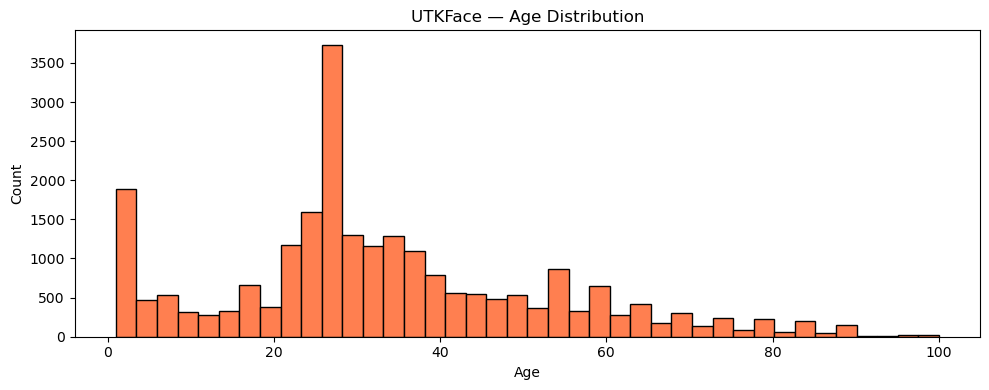

Min age : 1
Max age : 100
Mean age: 33.2


In [17]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

#### Finding 1 — Age Distribution is Heavily Skewed
The histogram shows a strong concentration of faces aged **20-40**.
Faces aged 70+ are severely underrepresented relative to the 20-29 group
(1,351 vs 7,344 images).

**Why this matters:** the model sees far more young/middle-aged faces during training,
so it learns those age groups much better than elderly or infant faces.

**How we address it:** class weights during training make the model pay more attention
to underrepresented groups like 0-2, 60-69 and 70+.

### UTKFace Age Group Distribution

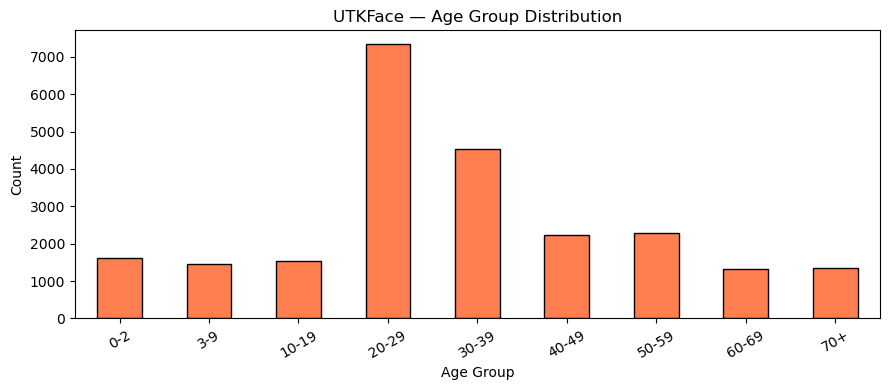

In [18]:
# reindex with AGE_GROUP_LABELS so bars appear in true age order
# (plain sort_index() would sort strings: "10-19" before "3-9")
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS).plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

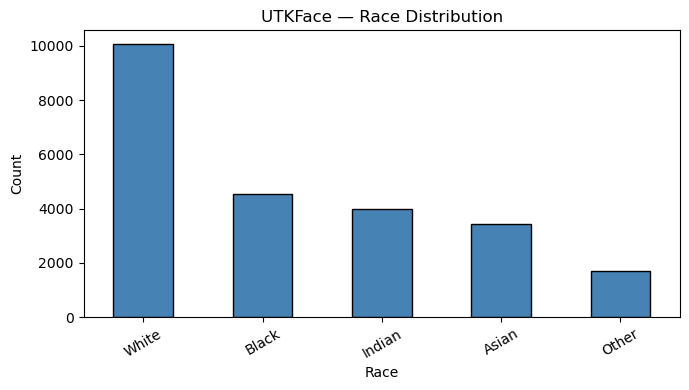

In [19]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 2 — White Faces Dominate UTKFace
White faces make up the largest group (~44%), followed by Black and Asian.
This is a known bias in datasets collected from Western internet sources.

**Why this matters:** a model trained on this imbalance may perform differently across
race categories.

**How we address it:** we measure per-race accuracy on the UTKFace test set and test
prediction consistency on FairFace, which is balanced across 7 races. Any gap we find
is quantified — not assumed.

### UTKFace Gender Distribution

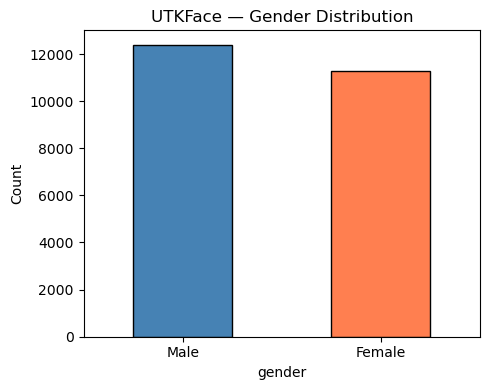

In [20]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 3 — Gender is Approximately Balanced
Male and female faces are roughly equal in UTKFace. This is a positive finding —
gender imbalance in training data is less of a concern.

**Note:** gender is never used as a model input. It is retained only to test whether
model accuracy differs by gender — measured in the Week 2 fairness analysis.

### Bias Check: Age by Race

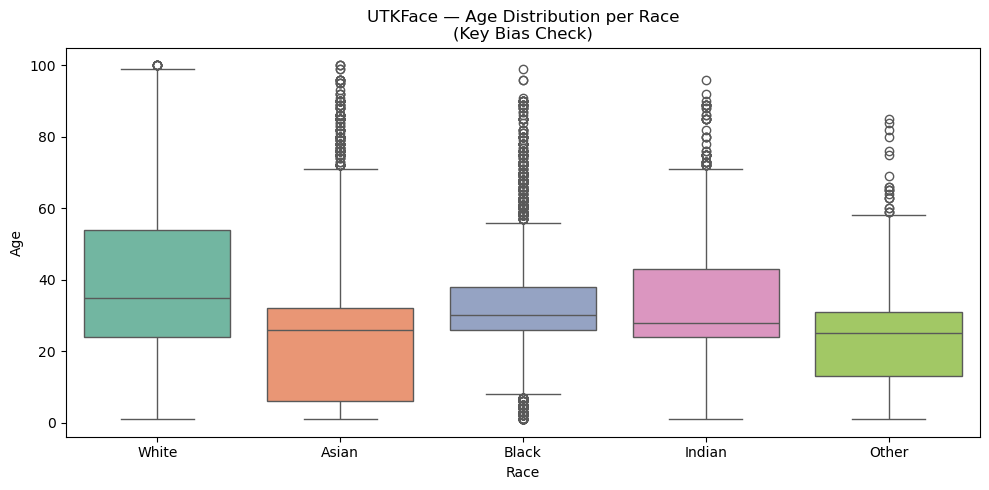

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### Finding 5 — Age Range Varies Across Races (Key Bias Risk)
The boxplot shows different age distributions across races in UTKFace. Some races have
fewer elderly or fewer young faces represented.

**What this means:** even with good overall accuracy, the model may fail on specific
age-race combinations that are underrepresented. If Indian elderly faces are rare in
training, the model may consistently predict Indian faces as younger than they are.

**This is the central fairness question our Week 2 analysis answers:**
does model accuracy differ systematically across race groups?

### Sample Images

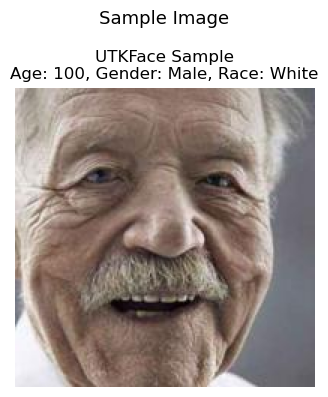

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
ax.imshow(img1)
ax.set_title(f"UTKFace Sample\n"
             f"Age: {df_utk_clean['age'].iloc[0]}, "
             f"Gender: {df_utk_clean['gender'].iloc[0]}, "
             f"Race: {df_utk_clean['race'].iloc[0]}")
ax.axis("off")

plt.suptitle("Sample Image", fontsize=13)
plt.tight_layout()
plt.show()

### EDA Summary

| Finding | Impact on Model |
|---|---|
| Young faces (20-40) dominate UTKFace | Model may underperform on elderly and infants |
| White faces outnumber others in UTKFace | Potential accuracy differences across races |
| Gender approximately balanced | Lower gender-bias risk — still verified in Week 2 |
| Minors present in UTKFace (4,233 images) | Documented — special care required in deployment |
| Age 70+ very underrepresented | Class weights applied during training |

**Next step → project plan, architecture and regulatory analysis, then model building.**

## Week 1: Project Plan & Architecture

### Problem Statement
We are building an age classification system for Alcohol Purchase Check. The system estimates
a customer's age group from a face image and must work fairly across all races and genders.

### Dataset Decision

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy tests | Continuous age labels, race, gender — most complete |

### Why MobileNetV2
- Lightweight — designed for devices without powerful GPUs (matches our CPU-only server)
- Pretrained on ImageNet — already understands generic visual features
- Transfer learning means far less training data and compute is needed
- Widely used in production retail and mobile systems

### Race-Agnostic Design
- Race is **never** an input to the model
- Gender is **never** an input to the model
- The model sees only raw pixel values
- Fairness is measured after training on UTKFace (accuracy)
- This prevents explicit use of protected attributes, while we still audit for implicit bias
  (the model can reconstruct race-correlated signal from pixels — see Risk R3)

### Training Strategy
- Full cleaned dataset: 23,684 images
- Split: 70% train / 15% validation / 15% test, **stratified on age group**
- Class weights compensate for imbalanced age groups
- Two-stage training: (1) frozen MobileNetV2 backbone, (2) fine-tune the last 30 layers
  at a low learning rate
- Optimizer: Adam · Loss: categorical cross-entropy · EarlyStopping on validation accuracy
- No data augmentation in the baseline — considered for Week 3 improvement

In [24]:
# Architecture diagram (display only)
from IPython.display import display, HTML

architecture_html = """
<div style="background:#f8f8f8; border-radius:12px; padding:20px; font-family:sans-serif; max-width:500px; margin:auto;">

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Input</b><br><span style="font-size:12px; color:#555;">Face image — 96×96 RGB</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Preprocessing</b><br>
    <span style="font-size:12px; color:#555;">Resize to 96×96 · Normalize pixels ÷ 255</span><br>
    <span style="font-size:11px; color:#c0392b;">⚠ Race & gender: never used as input</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>MobileNetV2 Backbone</b><br>
    <span style="font-size:12px; color:#555;">Pretrained ImageNet · Stage 1: frozen · Stage 2: last 30 layers fine-tuned</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fde8df; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>GlobalAveragePooling2D</b><br>
    <span style="font-size:12px; color:#555;">Compresses feature maps to a 1D vector</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fef3d6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dropout (0.5)</b><br>
    <span style="font-size:12px; color:#555;">Drops 50% of neurons — prevents overfitting</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 128 — ReLU</b><br>
    <span style="font-size:12px; color:#555;">Learns age-specific patterns</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 9 — Softmax</b><br>
    <span style="font-size:12px; color:#555;">One probability per age group</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px;">
    <b>Output: Age Group</b><br>
    <span style="font-size:11px; color:#555;">0-2 · 3-9 · 10-19 · 20-29 · 30-39 · 40-49 · 50-59 · 60-69 · 70+</span>
  </div>

</div>
"""

display(HTML(architecture_html))

---
## Week 1: Regulatory Analysis
---

Our system estimates a person's age group from a face image, intended for a Alcohol Purchase Check. Two regulations dominate: the **GDPR** and the **EU AI Act**.
We analyze both honestly, including where classification is genuinely ambiguous —
because getting the classification *right* matters more than defaulting to the
scariest label.

### 1. GDPR — General Data Protection Regulation (EU 2016/679)

**Are face images "biometric data" here?** Under Art. 4(14), biometric data is personal
data from technical processing of physical characteristics **which allows or confirms
the unique identification** of a person. Recital 51 clarifies that photographs are *not*
automatically special-category data — they become biometric data only when processed
through means that enable unique identification.

Our classifier does **not** identify anyone: it maps pixels to one of nine age groups
and discards the image. Strictly read, this may fall outside Art. 9 special-category
processing. However:

- The *training datasets* contain identifiable faces of real people who never consented
  to AI training use — that processing is squarely personal-data processing under GDPR.
- A deployed retail camera would capture images that *could* be used for identification,
  so a Data Protection Authority would likely apply the precautionary reading.

**We therefore treat the data as if Art. 9 applied** — the conservative position —
while documenting the legal nuance.

| Article | Requirement | How we address it |
|---|---|---|
| Art. 4(14) / Rec. 51 | Biometric-data definition | No unique identification performed; conservative Art. 9 treatment applied anyway |
| Art. 5(1)(c) | Data minimization | Only age (target), race and gender (audit-only), and filepath are retained; all other filename metadata dropped |
| Art. 5(1)(b) | Purpose limitation | Race/gender used exclusively for post-hoc fairness auditing, never as model input |
| Art. 6 / 9 | Lawful basis | Academic research context; no deployment. Commercial use would require explicit consent or another Art. 9(2) basis plus an Art. 6 basis |
| Art. 8 | Children's consent (Germany: 16) | Minors are present in UTKFace (4,233 images < 18). Retained for age-diversity in training; flagged as a hard deployment constraint |
| Art. 25 | Privacy by design | No face storage; aggregate age-group output only; protected attributes excluded from the model by construction |
| Art. 35 | DPIA | Systematic monitoring of a publicly accessible area with novel technology → DPIA mandatory before any real deployment |

### 2. EU AI Act (Regulation 2024/1689)

The classification question is subtler than it first appears, and we walk through it
explicitly:

**Prohibited (Art. 5)?** No. Art. 5(1)(g) prohibits biometric categorization that
*infers sensitive attributes* (race, political opinion, religion, sexual orientation…).
Age is not a sensitive attribute in this list, and our system is deliberately designed
**not** to infer race or gender. Real-time remote biometric *identification* in public
spaces (Art. 5(1)(h)) is also prohibited — we perform no identification.

**High-risk (Annex III)?** Annex III point 1(b) covers biometric categorization
*according to sensitive or protected attributes*. Age-group estimation does not
obviously fall under this. So unlike a naive reading, our system is **not clearly
high-risk** — but it is not clearly out of scope either, and guidance is still evolving.
A deployer should obtain a formal legal assessment.

**Transparency obligations (Art. 50)** apply in any case: people exposed to a biometric
categorization system must be informed of its operation. In a retail store this means
visible signage and accessible information — non-negotiable.

| Question | Answer |
|---|---|
| Prohibited practice? | No — no sensitive-attribute inference, no identification |
| High-risk (Annex III 1(b))? | Ambiguous — age is not a "sensitive or protected attribute"; conservative deployers should assume yes until guidance settles |
| Transparency (Art. 50)? | Yes — mandatory disclosure to affected persons |
| If treated as high-risk | Conformity assessment, risk-management system, per-demographic accuracy documentation, human oversight, EU database registration |

### 3. What this means for our project

This project is **research only**: no individuals are processed in real time, no faces
are stored or transmitted, no consequential decisions are made, and all results and
limitations are documented in this notebook. The per-demographic accuracy documentation
the AI Act would demand of a high-risk deployer is exactly what our Week 2 fairness
analysis produces — so our academic work doubles as the compliance groundwork a real
deployment would need.


---
# WEEK 2 - Baseline Model, Model Selection & Fairness
---

**Goals:** build a baseline age classifier, select a final model, and measure
whether its errors are distributed equally across race groups.

**What this section does**

| Step | Model | Purpose |
|---|---|---|
| 2a | **v1 baseline** - 96px MobileNetV2, no augmentation | establishes a floor |
| 2b | **v7 final** - 224px MobileNetV2 + augmentation + LR decay | the selected model |
| 2c | Fairness audit | per-race accuracy, parity gap for both |

Several architectures and training configurations were trialled during
development (different resolutions, augmentation settings, backbones and
optimisation schedules). **v7** was selected as the final model on the basis of
accuracy and one-off accuracy. Only the baseline and the selected model are
retained here; the intermediate trials are omitted for clarity.

**Fairness metrics used**
- **Accuracy parity gap** = best-group accuracy minus worst-group accuracy (percentage points)
- **Per-race accuracy** = accuracy computed separately for each race group

Race is **never an input** to either model - it is retained only as evaluation
metadata, so any measured gap arises from the images themselves.


### Train / Validation / Test Split

Stratified on the age label so every split has the same age distribution. Race is not used for stratification.

In [25]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split

AGE_GROUP_MAP = {label: i for i, label in enumerate(AGE_GROUP_LABELS)}
NUM_CLASSES   = len(AGE_GROUP_MAP)
SEED          = 42

df_utk_clean["label"] = df_utk_clean["age_group"].map(AGE_GROUP_MAP)

train_df, temp_df = train_test_split(
    df_utk_clean, test_size=0.30, stratify=df_utk_clean["label"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"Classes: {NUM_CLASSES}  ->  {AGE_GROUP_LABELS}")

# persist so later sections can run standalone
for name, d in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    d.to_csv(WORK_DIR / f"{name}.csv", index=False)
print("splits saved to", WORK_DIR)


Train 16,578 | Val 3,553 | Test 3,553
Classes: 9  ->  ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
splits saved to /home/jovyan/vault/data


### Load Images

Loaded once at both resolutions and held as **uint8** to keep memory low (~0.65 GB at 96px, ~3.6 GB at 224px). Normalisation happens inside each model's input pipeline, because the two models expect different ranges:

- **v1** was trained on `[0, 1]` - the pipeline divides by 255
- **v7** has a `Rescaling` layer built in - it receives raw `[0, 255]`

In [26]:
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

def load_images(df, size, workers=8):
    """Load images as uint8 [0,255]. Row i matches df.iloc[i]."""
    paths = df["filepath"].astype(str).values
    out   = np.zeros((len(paths), size, size, 3), np.uint8)
    def _one(i):
        out[i] = np.asarray(Image.open(paths[i]).convert("RGB")
                            .resize((size, size), Image.BILINEAR))
    with ThreadPoolExecutor(workers) as ex:
        list(ex.map(_one, range(len(paths))))
    return out

def onehot(df):
    return tf.keras.utils.to_categorical(df["label"].values, NUM_CLASSES).astype(np.float32)

# ---- 96px (for the v1 baseline) ----
X_tr96, X_va96, X_te96 = (load_images(d, 96) for d in (train_df, val_df, test_df))
# ---- 224px (for v7) ----
X_tr224, X_va224, X_te224 = (load_images(d, 224) for d in (train_df, val_df, test_df))

y_tr, y_va, y_te = onehot(train_df), onehot(val_df), onehot(test_df)
y_true_test = np.argmax(y_te, axis=1)

tot = sum(a.nbytes for a in [X_tr96, X_va96, X_te96, X_tr224, X_va224, X_te224]) / 1e9
print(f"96px  train {X_tr96.shape}   224px train {X_tr224.shape}")
print(f"image memory: {tot:.2f} GB (uint8)")


96px  train (16578, 96, 96, 3)   224px train (16578, 224, 224, 3)
image memory: 4.22 GB (uint8)


### Class Weights


In [27]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced",
                          classes=np.arange(NUM_CLASSES),
                          y=train_df["label"].values)
class_weight = {i: float(w) for i, w in enumerate(cw)}
w_train = np.array([class_weight[int(l)] for l in train_df["label"].values], np.float32)

for i, lab in enumerate(AGE_GROUP_LABELS):
    print(f"  {lab:<7} weight {class_weight[i]:.2f}   "
          f"n={int((train_df['label']==i).sum()):,}")


  0-2     weight 1.64   n=1,123
  3-9     weight 1.81   n=1,020
  10-19   weight 1.72   n=1,072
  20-29   weight 0.36   n=5,141
  30-39   weight 0.58   n=3,175
  40-49   weight 1.17   n=1,571
  50-59   weight 1.14   n=1,609
  60-69   weight 2.00   n=921
  70+     weight 1.95   n=946


### Data Pipeline Helper

In [28]:
BATCH_SIZE = 32

def make_ds(X, y, scale01=False, w=None, shuffle=False):
    """X: uint8 [0,255]. scale01=True divides by 255 (for v1)."""
    tensors = (X, y, w) if w is not None else (X, y)
    with tf.device("/CPU:0"):                 # keeps the big array off the GPU
        ds = tf.data.Dataset.from_tensor_slices(tensors)
    def _prep(a, b, *rest):
        a = tf.cast(a, tf.float32)
        if scale01:
            a = a / 255.0
        return (a, b) + rest
    ds = ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("pipeline ready")


pipeline ready


---
## Week 2a - Baseline Model (v1)
---

**MobileNetV2 @ 96px, ImageNet weights, no augmentation.**


In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import time

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

base_v1 = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base_v1.trainable = False

inp = layers.Input((96, 96, 3))
x   = base_v1(inp, training=False)            # no augmentation in the baseline
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dropout(0.5)(x)
x   = layers.Dense(128, activation="relu")(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_v1 = Model(inp, out, name="v1_baseline_96")

model_v1.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print(f"v1 parameters: {model_v1.count_params():,}")

tr1 = make_ds(X_tr96, y_tr, scale01=True, w=w_train, shuffle=True)
va1 = make_ds(X_va96, y_va, scale01=True)

t0 = time.time()
print("\n=== v1 STAGE 1 (frozen backbone) ===")
h1_v1 = model_v1.fit(tr1, validation_data=va1, epochs=26,
                     callbacks=[EarlyStopping(monitor="val_accuracy", patience=6,
                                              restore_best_weights=True, verbose=1)],
                     verbose=1)

print("\n=== v1 STAGE 2 (fine-tune last 30 layers) ===")
base_v1.trainable = True
for l in base_v1.layers[:-30]:
    l.trainable = False
model_v1.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss="categorical_crossentropy", metrics=["accuracy"])
h2_v1 = model_v1.fit(tr1, validation_data=va1, epochs=30,
                     callbacks=[EarlyStopping(monitor="val_accuracy", patience=6,
                                              restore_best_weights=True, verbose=1)],
                     verbose=1)

MODEL_V1 = WORK_DIR / "v1_baseline_96.keras"
model_v1.save(MODEL_V1)
print(f"\nv1 trained in {(time.time()-t0)/60:.1f} min  ->  {MODEL_V1.name}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
v1 parameters: 2,423,113

=== v1 STAGE 1 (frozen backbone) ===
Epoch 1/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.1945 - loss: 2.2262 - val_accuracy: 0.2857 - val_loss: 1.7908
Epoch 2/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.2787 - loss: 1.8189 - val_accuracy: 0.3355 - val_loss: 1.6728
Epoch 3/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3110 - loss: 1.7063 - val_accuracy: 0.3473 - val_loss: 1.6213
Epoch 4/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3305 - loss: 1.6423 - val_accuracy: 0.3594 - val_loss: 1.5648
Epoch 5/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3456 - loss: 1.5874 - val_accuracy: 0.3729 - val_loss: 1.5584
Epoch 6/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3584 - loss: 1.5634 - val_accuracy: 0.3634 - val_loss: 1.5659
Epoch 7/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3580 - loss: 1.5446 - val_accuracy: 0.36

### v1 Baseline - Test Results

In [30]:
te1 = make_ds(X_te96, y_te, scale01=True)
p_v1 = model_v1.predict(te1, verbose=0)
yp_v1 = np.argmax(p_v1, axis=1)

acc_v1    = float((yp_v1 == y_true_test).mean())
oneoff_v1 = float((np.abs(yp_v1 - y_true_test) <= 1).mean())

ev1 = test_df.copy()
ev1["y_pred"], ev1["correct"] = yp_v1, yp_v1 == y_true_test
race_v1 = ev1.groupby("race")["correct"].mean().sort_values()
gap_v1  = float(race_v1.max() - race_v1.min())

print(f"=== v1 BASELINE (96px, no augmentation) ===")
print(f"  exact-band accuracy : {acc_v1:.2%}")
print(f"  one-off accuracy    : {oneoff_v1:.2%}\n")
for r, v in race_v1.items():
    print(f"    {r:<8} {v:.2%}")
print(f"\n  accuracy parity gap : {gap_v1*100:.2f}pp "
      f"(best {race_v1.idxmax()}, worst {race_v1.idxmin()})")


=== v1 BASELINE (96px, no augmentation) ===
  exact-band accuracy : 47.14%
  one-off accuracy    : 84.21%

    Black    40.47%
    White    44.52%
    Indian   50.78%
    Other    55.00%
    Asian    56.32%

  accuracy parity gap : 15.85pp (best Asian, worst Black)


---
## Week 2b - Final Model (v7)
---

After trialling several configurations - different input resolutions, backbones,
augmentation settings and optimisation schedules - **v7** was selected as the
final model.

**What v7 changes relative to the baseline**

| | v1 baseline | v7 final |
|---|---|---|
| Input resolution | 96 x 96 | **224 x 224** |
| Augmentation | none | **flip, rotation, zoom, contrast** |
| Input scaling | `[0,1]` | **`[-1,1]` via a built-in `Rescaling` layer** |
| Fine-tuning | last 30 layers | **full backbone unfrozen** |
| Schedule | fixed LR | **ReduceLROnPlateau + EarlyStopping on `val_accuracy`** |



In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.10, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="augmentation")

base_v7 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_v7.trainable = False

inp = layers.Input((224, 224, 3))
x   = aug(inp)
x   = layers.Rescaling(1/127.5, offset=-1.0)(x)     # [0,255] -> [-1,1]
x   = base_v7(x, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, use_bias=False)(x)
x   = layers.BatchNormalization()(x)
x   = layers.ReLU()(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_v7 = Model(inp, out, name="v7_final_224")
print(f"v7 parameters: {model_v7.count_params():,}")

tr7 = make_ds(X_tr224, y_tr, w=w_train, shuffle=True)   # raw [0,255]
va7 = make_ds(X_va224, y_va)

MODEL_V7 = WORK_DIR / "v7_final_224.keras"
t0 = time.time()

model_v7.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print("\n=== v7 STAGE 1 (frozen backbone, warm-up) ===")
h1_v7 = model_v7.fit(tr7, validation_data=va7, epochs=5, verbose=1)

base_v7.trainable = True
model_v7.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print("\n=== v7 STAGE 2 (full unfreeze + LR decay) ===")
h2_v7 = model_v7.fit(
    tr7, validation_data=va7, epochs=35,
    callbacks=[
        ReduceLROnPlateau(monitor="val_accuracy", mode="max", factor=0.4,
                          patience=3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor="val_accuracy", mode="max", patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(str(MODEL_V7), monitor="val_accuracy", mode="max",
                        save_best_only=True),
    ], verbose=1)

model_v7.save(MODEL_V7)
print(f"\nv7 trained in {(time.time()-t0)/60:.1f} min  ->  {MODEL_V7.name}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
v7 parameters: 2,589,001

=== v7 STAGE 1 (frozen backbone, warm-up) ===
Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - accuracy: 0.3422 - loss: 1.6841 - val_accuracy: 0.3172 - val_loss: 1.6320
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.3864 - loss: 1.4501 - val_accuracy: 0.3099 - val_loss: 1.6334
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.4053 - loss: 1.3911 - val_accuracy: 0.3890 - val_loss: 1.4712
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.4202 - loss: 1.3528 - val_accuracy: 0.3577 - val_loss: 1.5400
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 62s 120ms/step - accuracy: 0.4331 - loss: 1.3259 - val_accuracy: 0.3681 - val_loss: 1.5388

=== v7 STAGE 2 (full unfreeze + LR decay) ===
Epoch 1/35
519/519 ━━━━━━━━━━━━━━━━━━━━ 305s 562ms/step - accuracy: 0.3855 - loss: 1.4775 - val_accuracy: 0.4500 - val_loss: 1.5597 - learning_rate: 1.0000e-04
Epoch 2/35
519/519 ━━━

### v7 Final - Test Results

In [32]:
te7 = make_ds(X_te224, y_te)
p_v7  = model_v7.predict(te7, verbose=0)
yp_v7 = np.argmax(p_v7, axis=1)

acc_v7    = float((yp_v7 == y_true_test).mean())
oneoff_v7 = float((np.abs(yp_v7 - y_true_test) <= 1).mean())

test_eval = test_df.copy()
test_eval["y_true"]  = y_true_test
test_eval["y_pred"]  = yp_v7
test_eval["correct"] = yp_v7 == y_true_test
race_v7 = test_eval.groupby("race")["correct"].mean().sort_values()
gap_v7  = float(race_v7.max() - race_v7.min())

print(f"=== v7 FINAL (224px + augmentation + LR decay) ===")
print(f"  exact-band accuracy : {acc_v7:.2%}")
print(f"  one-off accuracy    : {oneoff_v7:.2%}\n")
for r, v in race_v7.items():
    print(f"    {r:<8} {v:.2%}")
print(f"\n  accuracy parity gap : {gap_v7*100:.2f}pp "
      f"(best {race_v7.idxmax()}, worst {race_v7.idxmin()})")


=== v7 FINAL (224px + augmentation + LR decay) ===
  exact-band accuracy : 54.94%
  one-off accuracy    : 90.29%

    White    51.10%
    Black    51.76%
    Indian   55.30%
    Other    61.67%
    Asian    67.39%

  accuracy parity gap : 16.29pp (best Asian, worst White)


### Week 2c - Baseline vs Final

,metric,v1 baseline (96px),v7 final (224px)
0,exact accuracy,47.14%,54.94%
1,one-off accuracy,84.21%,90.29%
2,race parity gap (pp),15.85,16.29


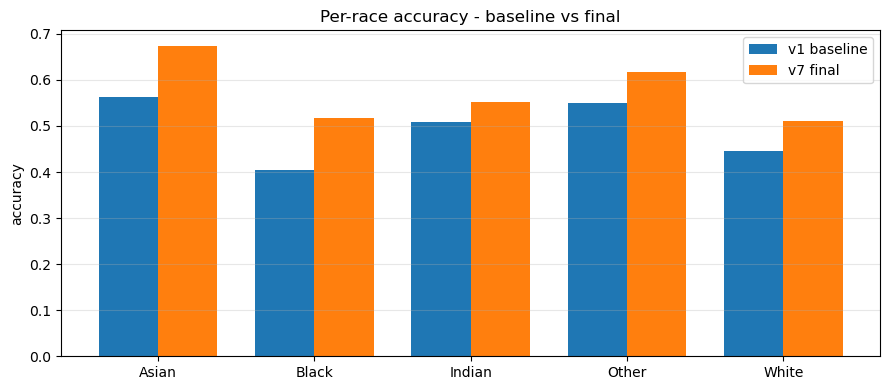

accuracy   47.14% -> 54.94%   (+7.80pp)
one-off    84.21% -> 90.29%   (+6.08pp)
race gap   15.85pp -> 16.29pp   (+0.44pp)


In [33]:
import matplotlib.pyplot as plt

cmp = pd.DataFrame({
    "metric": ["exact accuracy", "one-off accuracy", "race parity gap (pp)"],
    "v1 baseline (96px)": [f"{acc_v1:.2%}", f"{oneoff_v1:.2%}", f"{gap_v1*100:.2f}"],
    "v7 final (224px)"  : [f"{acc_v7:.2%}", f"{oneoff_v7:.2%}", f"{gap_v7*100:.2f}"],
})
display(cmp)

fig, ax = plt.subplots(figsize=(9, 4))
races = sorted(set(race_v1.index) | set(race_v7.index))
xs = np.arange(len(races)); w = 0.38
ax.bar(xs - w/2, [race_v1.get(r, 0) for r in races], w, label="v1 baseline")
ax.bar(xs + w/2, [race_v7.get(r, 0) for r in races], w, label="v7 final")
ax.set_xticks(xs); ax.set_xticklabels(races)
ax.set_ylabel("accuracy"); ax.set_title("Per-race accuracy - baseline vs final")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(f"accuracy   {acc_v1:.2%} -> {acc_v7:.2%}   ({(acc_v7-acc_v1)*100:+.2f}pp)")
print(f"one-off    {oneoff_v1:.2%} -> {oneoff_v7:.2%}   ({(oneoff_v7-oneoff_v1)*100:+.2f}pp)")
print(f"race gap   {gap_v1*100:.2f}pp -> {gap_v7*100:.2f}pp   "
      f"({(gap_v7-gap_v1)*100:+.2f}pp)")


---
# WEEK 3 - Explainability, Error Structure & Statistical Confidence
---

All analysis in this section uses the **final model, v7**.

**Goals**
- open the model with an XAI method (Grad-CAM) and compare **where the baseline
  and the final model look**
- quantify the *structure* of the errors (confusion matrix, one-off accuracy)
- locate intersectional failure cells (per-age x per-race grid)
- put confidence bounds on the fairness gap (bootstrap)


## XAI Method: Grad-CAM


In [34]:
def _unwrap(t):
    return t[0] if isinstance(t, (list, tuple)) else t

def make_gradcam(m):
    """Works for a flat model and for one with a nested backbone."""
    base = next((l for l in m.layers
                 if isinstance(l, tf.keras.Model) and len(l.layers) > 10), None)
    if base is not None:                                  # nested (v1 and v7 both)
        head = m.layers[m.layers.index(base) + 1:]
        def f(x):
            with tf.GradientTape() as t:
                conv = base(x, training=False)
                t.watch(conv)
                h = conv
                for l in head:
                    h = l(h, training=False)
                ch = h[:, tf.argmax(h[0])]
            return conv, t.gradient(ch, conv)
        return f, f"{base.name}/{base.layers[-1].name}"
    target = [l for l in m.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
    gm = tf.keras.Model(_unwrap(m.input), [_unwrap(target.output), _unwrap(m.output)])
    def f(x):
        with tf.GradientTape() as t:
            conv, pred = gm(x, training=False)
            ch = pred[:, tf.argmax(pred[0])]
        return conv, t.gradient(ch, conv)
    return f, target.name

def heatmap(gc, x):
    conv, grads = gc(x)
    w  = tf.reduce_mean(grads, axis=(0, 1, 2))
    hm = tf.squeeze(conv[0] @ w[:, tf.newaxis])
    hm = tf.maximum(hm, 0)
    return (hm / (tf.reduce_max(hm) + 1e-8)).numpy()

gc_v1, layer_v1 = make_gradcam(model_v1)
gc_v7, layer_v7 = make_gradcam(model_v7)
print(f"v1 tap: {layer_v1}   heatmap {heatmap(gc_v1, X_te96[0:1].astype(np.float32)/255.).shape}")
print(f"v7 tap: {layer_v7}   heatmap {heatmap(gc_v7, X_te224[0:1].astype(np.float32)).shape}")


v1 tap: mobilenetv2_1.00_96/out_relu   heatmap (3, 3)
v7 tap: mobilenetv2_1.00_224/out_relu   heatmap (7, 7)


### Grad-CAM: Baseline vs Final on the Same Faces

Same four test faces through both models. Red marks the regions that drove each prediction.

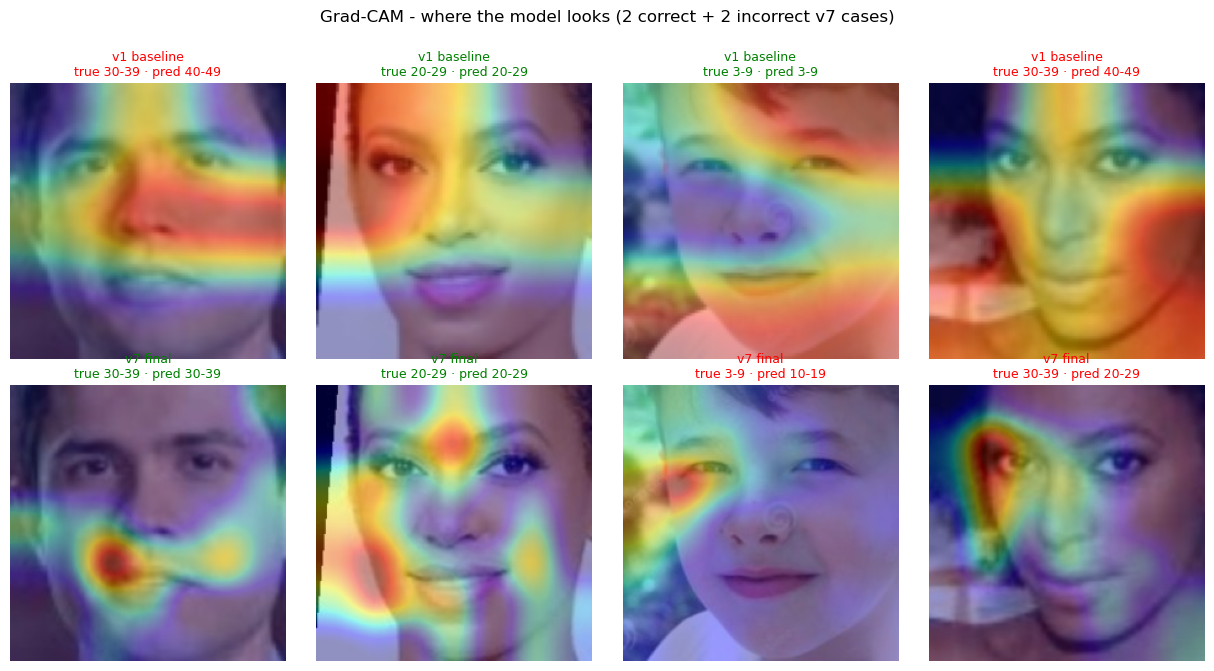

In [35]:
# --- one batched pass to find correct vs incorrect (based on v7, the final model) ---
pred_v7_all = model_v7.predict(X_te224, verbose=0).argmax(1)
correct_idx = np.where(pred_v7_all == y_true_test)[0]
wrong_idx   = np.where(pred_v7_all != y_true_test)[0]

rng   = np.random.default_rng(SEED)
picks = np.concatenate([
    rng.choice(correct_idx, 2, replace=False),   # 2 where v7 is right
    rng.choice(wrong_idx,   2, replace=False),   # 2 where v7 is wrong
])

fig, axes = plt.subplots(2, len(picks), figsize=(3.1*len(picks), 6.6))
for c, idx in enumerate(picks):
    true = AGE_GROUP_LABELS[y_true_test[idx]]
    for r, (tag, gc, X, scale, mdl) in enumerate([
            ("v1 baseline", gc_v1, X_te96,  True,  model_v1),
            ("v7 final",    gc_v7, X_te224, False, model_v7)]):
        x = X[idx:idx+1].astype(np.float32)
        if scale: x = x / 255.0
        hm   = heatmap(gc, x)
        pred = AGE_GROUP_LABELS[int(np.argmax(mdl.predict(x, verbose=0)[0]))]
        big  = np.array(Image.fromarray(np.uint8(255*hm)).resize(
                            (X.shape[1], X.shape[1])))
        axes[r, c].imshow(X[idx]); axes[r, c].imshow(big, cmap="jet", alpha=0.40)
        axes[r, c].axis("off")
        axes[r, c].set_title(f"{tag}\ntrue {true} · pred {pred}", fontsize=9,
                             color="green" if pred == true else "red")

plt.suptitle("Grad-CAM - where the model looks (2 correct + 2 incorrect v7 cases)",
             y=1.01)
plt.tight_layout(); plt.show()

### Attention by Facial Region

Each heat map is resized to a common 24x24 grid and split into vertical thirds, so the two resolutions are directly comparable and each band covers exactly one third of the face.

In [36]:
GRID, N_PER_RACE = 24, 80

def region_profile(gc, X, scale, idxs):
    acc = []
    for i in idxs:
        x = X[i:i+1].astype(np.float32)
        if scale: x = x / 255.0
        hm = heatmap(gc, x)
        hm = tf.image.resize(hm[..., None], [GRID, GRID]).numpy().squeeze()
        s  = hm.sum()
        if s == 0: continue
        hm, t3 = hm/s, GRID//3
        acc.append((hm[:t3].sum()*100, hm[t3:2*t3].sum()*100, hm[2*t3:].sum()*100))
    return np.mean(acc, axis=0)

rows = []
for tag, gc, X, scale in [("v1 baseline", gc_v1, X_te96,  True),
                          ("v7 final",    gc_v7, X_te224, False)]:
    print(f"\n=== {tag} ===")
    print(f"  {'race':<8}{'TOP':>8}{'MID':>8}{'LOW':>8}")
    per = {}
    for race in sorted(test_df["race"].unique()):
        idxs = test_df.index[test_df["race"] == race][:N_PER_RACE]
        per[race] = region_profile(gc, X, scale, idxs)
        print(f"  {race:<8}{per[race][0]:>7.1f}{per[race][1]:>8.1f}{per[race][2]:>8.1f}")
    arr    = np.array(list(per.values()))
    spread = arr.max(axis=0) - arr.min(axis=0)
    rows.append((tag, arr.mean(axis=0), spread))
    print(f"  mean    {arr.mean(axis=0)[0]:>7.1f}{arr.mean(axis=0)[1]:>8.1f}"
          f"{arr.mean(axis=0)[2]:>8.1f}")
    print(f"  spread across races: {spread.sum():.2f}")

print(f"\n{'='*64}")
print("TOP = forehead/hair · MID = eyes/nose · LOW = mouth/chin")
print(f"{'Model':<16}{'TOP':>9}{'MID':>9}{'LOW':>9}{'race spread':>14}")
for tag, mean, spread in rows:
    print(f"{tag:<16}{mean[0]:>8.1f}{mean[1]:>9.1f}{mean[2]:>9.1f}{spread.sum():>13.2f}")
print("\nHigher MID share = more attention on the eye/nose region, where ageing")
print("cues concentrate. Lower race spread = more uniform attention across groups.")



=== v1 baseline ===
  race         TOP     MID     LOW
  Asian      38.5    34.7    26.9
  Black      32.4    37.4    30.2
  Indian     39.4    34.6    26.0
  Other      37.3    34.3    28.4
  White      36.5    36.6    26.9
  mean       36.8    35.5    27.6
  spread across races: 14.30

=== v7 final ===
  race         TOP     MID     LOW
  Asian      26.6    49.7    23.6
  Black      30.2    44.2    25.6
  Indian     30.7    46.8    22.5
  Other      29.1    46.1    24.8
  White      32.4    45.8    21.8
  mean       29.8    46.5    23.7
  spread across races: 15.09

TOP = forehead/hair · MID = eyes/nose · LOW = mouth/chin
Model                 TOP      MID      LOW   race spread
v1 baseline         36.8     35.5     27.6        14.30
v7 final            29.8     46.5     23.7        15.09

Higher MID share = more attention on the eye/nose region, where ageing
cues concentrate. Lower race spread = more uniform attention across groups.


## Confusion Matrix (9 age groups)

Row-normalised, so each row sums to 1 and the diagonal is per-class recall.

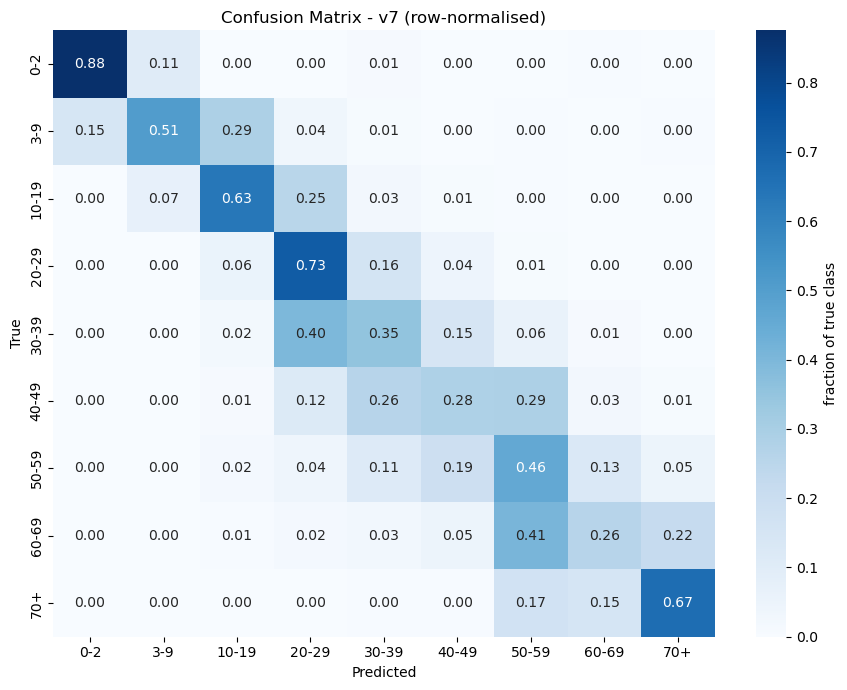

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true_test, yp_v7, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=AGE_GROUP_LABELS, yticklabels=AGE_GROUP_LABELS,
            cbar_kws={"label": "fraction of true class"})
plt.title("Confusion Matrix - v7 (row-normalised)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


In [38]:
exact    = float((y_true_test == yp_v7).mean())
adjacent = float((np.abs(y_true_test - yp_v7) == 1).mean())
far      = float((np.abs(y_true_test - yp_v7) >= 2).mean())

print(f"Exact correct          : {exact:.2%}")
print(f"Off by exactly 1 band  : {adjacent:.2%}")
print(f"Off by 2+ bands        : {far:.2%}")
print(f"\n-> one-off accuracy   : {exact + adjacent:.2%}")
print("\nErrors concentrated next to the diagonal mean the model is rarely")
print("badly wrong - the operationally relevant property for age estimation.")


Exact correct          : 54.94%
Off by exactly 1 band  : 35.35%
Off by 2+ bands        : 9.71%

-> one-off accuracy   : 90.29%

Errors concentrated next to the diagonal mean the model is rarely
badly wrong - the operationally relevant property for age estimation.


## Per-Age x Per-Race Accuracy Grid


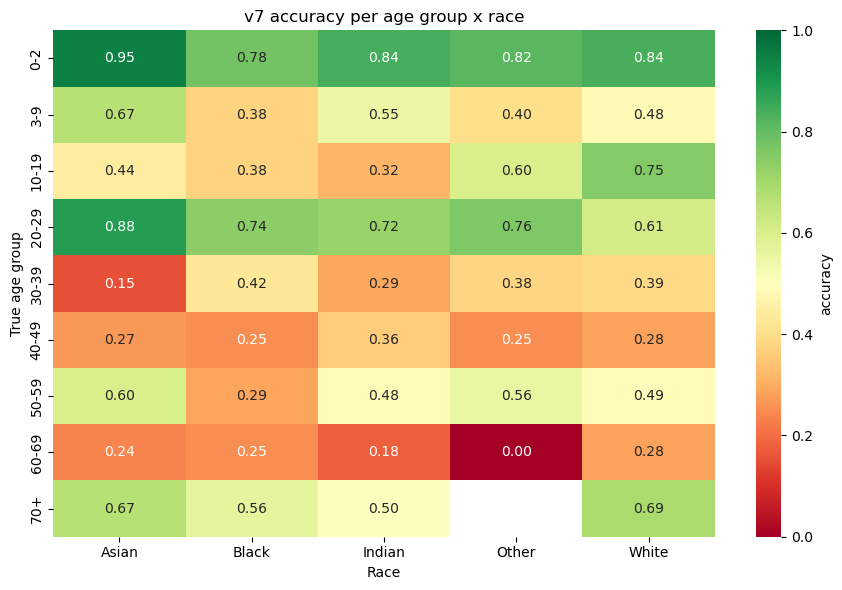

Test-image count per cell (n < 15 is unreliable):

race       Asian  Black  Indian  Other  White
age_group                                    
0-2           95      9      44     38     55
3-9           36      8      31     25    118
10-19          9     32      19     25    144
20-29        197    269     237     92    307
30-39         85    196     103     34    263
40-49         30     64      50     16    177
50-59         10     52      64      9    210
60-69         17     36      17      1    127
70+           27     16      10      0    149

=== WEAKEST RELIABLE CELLS (n >= 15) ===
  Asian    30-39   15.3%  (n=85)
  Indian   60-69   17.6%  (n=17)
  Asian    60-69   23.5%  (n=17)
  Other    40-49   25.0%  (n=16)
  Black    60-69   25.0%  (n=36)
  Black    40-49   25.0%  (n=64)
  Asian    40-49   26.7%  (n=30)
  White    40-49   28.2%  (n=177)


In [39]:
grid_acc = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="mean").reindex(AGE_GROUP_LABELS)
grid_n   = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="count").reindex(AGE_GROUP_LABELS)

plt.figure(figsize=(9, 6))
sns.heatmap(grid_acc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "accuracy"})
plt.title("v7 accuracy per age group x race")
plt.xlabel("Race"); plt.ylabel("True age group")
plt.tight_layout(); plt.show()

print("Test-image count per cell (n < 15 is unreliable):\n")
print(grid_n.fillna(0).astype(int))

flat = [(grid_acc.loc[a, r], grid_n.loc[a, r], a, r)
        for a in grid_acc.index for r in grid_acc.columns
        if pd.notna(grid_n.loc[a, r]) and grid_n.loc[a, r] >= 15]
flat.sort()
print("\n=== WEAKEST RELIABLE CELLS (n >= 15) ===")
for a, n, age, race in flat[:8]:
    print(f"  {race:<8} {age:<7} {a:.1%}  (n={int(n)})")


## Per-Group Recall (equal-opportunity view)

In [40]:
print("=== PER-AGE-GROUP RECALL (v7, all races) ===\n")
print(classification_report(y_true_test, yp_v7,
                            target_names=AGE_GROUP_LABELS, zero_division=0))

print("\n=== MACRO-AVERAGED RECALL PER RACE ===\n")
for race in sorted(test_eval["race"].unique()):
    sub = test_eval[test_eval["race"] == race]
    rec = classification_report(sub["y_true"], sub["y_pred"],
                                output_dict=True, zero_division=0)["macro avg"]["recall"]
    print(f"  {race:<8} macro recall {rec:.2%}   (n={len(sub):,})")


=== PER-AGE-GROUP RECALL (v7, all races) ===

              precision    recall  f1-score   support

         0-2       0.86      0.88      0.87       241
         3-9       0.72      0.51      0.60       218
       10-19       0.49      0.63      0.55       229
       20-29       0.67      0.73      0.70      1102
       30-39       0.43      0.35      0.39       681
       40-49       0.30      0.28      0.29       337
       50-59       0.37      0.46      0.41       345
       60-69       0.36      0.26      0.30       198
         70+       0.67      0.67      0.67       202

    accuracy                           0.55      3553
   macro avg       0.54      0.53      0.53      3553
weighted avg       0.55      0.55      0.54      3553


=== MACRO-AVERAGED RECALL PER RACE ===

  Asian    macro recall 54.04%   (n=506)
  Black    macro recall 44.91%   (n=682)
  Indian   macro recall 47.10%   (n=575)
  Other    macro recall 41.83%   (n=240)
  White    macro recall 53.47%   (n=1,550)


## Statistical Confidence: Bootstrap CIs on Per-Race Accuracy

In [41]:
rng    = np.random.default_rng(SEED)
N_BOOT = 1000

print("=== 95% BOOTSTRAP CI PER RACE (v7) ===\n")
race_accuracies, ci = {}, {}
for race in sorted(test_eval["race"].unique()):
    sub = test_eval[test_eval["race"] == race]
    idx = sub.index.to_numpy()
    race_accuracies[race] = float(sub["correct"].mean())
    boot = [test_eval.loc[rng.choice(idx, len(idx), replace=True), "correct"].mean()
            for _ in range(N_BOOT)]
    ci[race] = tuple(np.percentile(boot, [2.5, 97.5]))
    print(f"  {race:<8} {race_accuracies[race]:.2%}   "
          f"CI [{ci[race][0]:.2%}, {ci[race][1]:.2%}]   (n={len(sub):,})")

best  = max(race_accuracies, key=race_accuracies.get)
worst = min(race_accuracies, key=race_accuracies.get)
gap   = race_accuracies[best] - race_accuracies[worst]
overlap = ci[best][0] <= ci[worst][1]

print(f"\n  gap {best} - {worst}: {gap*100:.2f}pp")
print(f"  CIs overlap: {overlap}  ->  the gap is",
      "NOT clearly separable from sampling noise" if overlap else
      "statistically credible (not sampling noise)")


=== 95% BOOTSTRAP CI PER RACE (v7) ===

  Asian    67.39%   CI [63.44%, 71.15%]   (n=506)
  Black    51.76%   CI [48.09%, 55.43%]   (n=682)
  Indian   55.30%   CI [51.30%, 59.48%]   (n=575)
  Other    61.67%   CI [55.42%, 67.92%]   (n=240)
  White    51.10%   CI [48.64%, 53.55%]   (n=1,550)

  gap Asian - White: 16.29pp
  CIs overlap: False  ->  the gap is statistically credible (not sampling noise)


## Week 3 Summary

| Analysis | What it answers |
|---|---|
| Grad-CAM, baseline vs final | *Where* each model looks, and how attention shifted |
| Confusion matrix + one-off | *How* the model errs - adjacent bands or far misses |
| Per-age x per-race grid | *Which* intersectional cells fail |
| Per-group recall | Equal-opportunity view beyond raw accuracy |
| Bootstrap CIs | Whether the measured fairness gap survives statistical scrutiny |

Race is never an input to the model, yet a measurable per-race accuracy gap
remains. Removing a protected attribute from the input does not remove bias from
the output - the images themselves carry race-correlated signal, so fairness must
be **measured** rather than assumed from the architecture.


---
# WEEK 4 - Automated Tests & Deployment
---

**Goals:** automated weakness-detection tests with code coverage, a fairness
regression check on the live model, and a deployed web application.


## Automated Tests (pytest with coverage)

Pipeline logic is extracted to a module so it can be imported and tested independently of the notebook.

In [42]:
%%writefile responsible_ai_utils.py
"""Pure pipeline logic extracted from the notebook so pytest can import and test it.
Kept in exact sync with the notebook definitions."""

AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}


def age_to_group(age):
    """Bin a continuous age into one of 9 canonical age groups."""
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"


def parse_utk_filename(stem):
    """Parse a UTKFace filename stem 'age_gender_race_timestamp'.
    Returns a dict or None for malformed / non-numeric stems."""
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    try:
        return {
            "age"    : int(parts[0]),
            "gender" : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"   : RACE_MAP.get(int(parts[2]),   "Unknown"),
        }
    except ValueError:
        return None


def clean_utk(df):
    """Apply the notebook's cleaning rules: age 1-100, no Unknown labels,
    add the age_group column."""
    out = df.copy()
    out = out[out["age"] >= 1]
    out = out[out["age"] <= 100]
    out = out[out["gender"] != "Unknown"]
    out = out[out["race"]   != "Unknown"]
    out["age_group"] = out["age"].apply(age_to_group)
    return out


def splits_disjoint(*dfs, col="filepath"):
    """True iff no filepath appears in more than one split."""
    seen = set()
    for df in dfs:
        values = set(df[col])
        if seen & values:
            return False
        seen |= values
    return True


def one_off_correct(y_true, y_pred):
    """Fraction of predictions within one age group of the truth."""
    import numpy as np
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.abs(y_true - y_pred) <= 1).mean())


def accuracy_parity_gap(acc_dict):
    """Best-minus-worst group accuracy — our named fairness metric."""
    return max(acc_dict.values()) - min(acc_dict.values())


def fairness_check(acc_dict, max_gap):
    """Weakness detection: True iff the accuracy parity gap is within threshold."""
    return accuracy_parity_gap(acc_dict) <= max_gap


Overwriting responsible_ai_utils.py


In [43]:
%%writefile test_responsible_ai.py
"""Automated test suite — run with:
    pytest test_responsible_ai.py -v --cov=responsible_ai_utils --cov-report=term
"""
import numpy as np
import pandas as pd
import pytest

from responsible_ai_utils import (age_to_group, parse_utk_filename, clean_utk,
                                  splits_disjoint, one_off_correct,
                                  accuracy_parity_gap, fairness_check,
                                  AGE_GROUP_LABELS)


# ---------- age_to_group: every boundary value ----------
@pytest.mark.parametrize("age,expected", [
    (1,  "0-2"),  (2,  "0-2"),
    (3,  "3-9"),  (9,  "3-9"),
    (10, "10-19"), (19, "10-19"),
    (20, "20-29"), (29, "20-29"),
    (30, "30-39"), (39, "30-39"),
    (40, "40-49"), (49, "40-49"),
    (50, "50-59"), (59, "50-59"),
    (60, "60-69"), (69, "60-69"),
    (70, "70+"),   (100, "70+"),
])
def test_age_to_group_boundaries(age, expected):
    assert age_to_group(age) == expected


def test_age_groups_are_canonical():
    # every produced label must be one of the 9 canonical labels
    for age in range(1, 101):
        assert age_to_group(age) in AGE_GROUP_LABELS


# ---------- filename parsing ----------
def test_parse_valid_filename():
    r = parse_utk_filename("25_0_2_20170116174525125")
    assert r == {"age": 25, "gender": "Male", "race": "Asian"}

def test_parse_female_white():
    r = parse_utk_filename("61_1_0_20170109150557335")
    assert r == {"age": 61, "gender": "Female", "race": "White"}

def test_parse_too_few_parts_returns_none():
    assert parse_utk_filename("25_0") is None

def test_parse_non_numeric_returns_none():
    assert parse_utk_filename("abc_0_1_xyz") is None

def test_parse_unknown_codes_mapped():
    r = parse_utk_filename("30_7_9_ts")           # invalid gender/race codes
    assert r["gender"] == "Unknown" and r["race"] == "Unknown"


# ---------- cleaning rules ----------
def _toy_df():
    return pd.DataFrame({
        "filepath": [f"f{i}.jpg" for i in range(6)],
        "age"     : [0, 1, 50, 100, 116, 30],
        "gender"  : ["Male", "Female", "Male", "Female", "Male", "Unknown"],
        "race"    : ["White", "Black", "Unknown", "Asian", "Indian", "Other"],
    })

def test_clean_removes_age_zero_and_over_100():
    out = clean_utk(_toy_df())
    assert out["age"].min() >= 1
    assert out["age"].max() <= 100

def test_clean_removes_unknown_labels():
    out = clean_utk(_toy_df())
    assert "Unknown" not in out["gender"].values
    assert "Unknown" not in out["race"].values

def test_clean_adds_valid_age_group_column():
    out = clean_utk(_toy_df())
    assert "age_group" in out.columns
    assert out["age_group"].isin(AGE_GROUP_LABELS).all()

def test_clean_keeps_expected_rows():
    # rows 1 (age 1) and 3 (age 100) survive; 0, 2, 4, 5 are filtered
    out = clean_utk(_toy_df())
    assert set(out["filepath"]) == {"f1.jpg", "f3.jpg"}


# ---------- split integrity ----------
def test_splits_disjoint_true_for_clean_splits():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["c.jpg"]})
    c = pd.DataFrame({"filepath": ["d.jpg", "e.jpg"]})
    assert splits_disjoint(a, b, c)

def test_splits_disjoint_detects_leakage():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["b.jpg"]})      # leaked into validation
    assert not splits_disjoint(a, b)


# ---------- metrics ----------
def test_one_off_correct():
    y_true = [3, 3, 3, 3]
    y_pred = [3, 4, 2, 6]        # exact, +1, -1, far
    assert one_off_correct(y_true, y_pred) == pytest.approx(0.75)

def test_accuracy_parity_gap():
    assert accuracy_parity_gap({"A": 0.55, "B": 0.42}) == pytest.approx(0.13)

def test_fairness_check_passes_within_threshold():
    assert fairness_check({"A": 0.50, "B": 0.45}, max_gap=0.10)

def test_fairness_check_fails_beyond_threshold():
    assert not fairness_check({"A": 0.56, "B": 0.42}, max_gap=0.10)


Overwriting test_responsible_ai.py


In [44]:
!pip install pytest pytest-cov -q
# -p no:langsmith_plugin disables an unrelated, broken pytest plugin (langsmith,
# pulled in by other coursework) that would crash pytest at startup. Harmless if
# langsmith isn't installed (e.g. on the cloud JupyterHub).
!pytest test_responsible_ai.py -v -p no:langsmith_plugin --cov=responsible_ai_utils --cov-report=term

============================= test session starts ==============================
platform linux -- Python 3.13.11, pytest-9.1.1, pluggy-1.6.0 -- /opt/conda/bin/python3.13
cachedir: .pytest_cache
rootdir: /home/jovyan/vault
plugins: cov-7.1.0, anyio-4.12.0
collected 34 items                                                             

test_responsible_ai.py::test_age_to_group_boundaries[1-0-2] PASSED       [  2%]
test_responsible_ai.py::test_age_to_group_boundaries[2-0-2] PASSED       [  5%]
test_responsible_ai.py::test_age_to_group_boundaries[3-3-9] PASSED       [  8%]
test_responsible_ai.py::test_age_to_group_boundaries[9-3-9] PASSED       [ 11%]
test_responsible_ai.py::test_age_to_group_boundaries[10-10-19] PASSED    [ 14%]
test_responsible_ai.py::test_age_to_group_boundaries[19-10-19] PASSED    [ 17%]
test_responsible_ai.py::test_age_to_group_boundaries[20-20-29] PASSED    [ 20%]
test_responsible_ai.py::test_age_to_group_boundaries[29-20-29] PASSED    [ 23%]
test_responsible_ai.py:

## Weakness Detection: Live Fairness Regression Check

A guard that fails if the per-race accuracy gap exceeds an agreed threshold - the kind of check that would gate a deployment.

In [45]:
from responsible_ai_utils import accuracy_parity_gap, fairness_check

MAX_ALLOWED_GAP = 0.20      # 20pp policy ceiling

gap_now = accuracy_parity_gap(race_accuracies)
passed  = fairness_check(race_accuracies, MAX_ALLOWED_GAP)

print("=== LIVE FAIRNESS REGRESSION CHECK (v7) ===\n")
for r, a in sorted(race_accuracies.items(), key=lambda kv: kv[1]):
    print(f"  {r:<8} {a:.2%}")
print(f"\n  measured gap : {gap_now*100:.2f}pp")
print(f"  threshold    : {MAX_ALLOWED_GAP*100:.0f}pp")
print(f"  result       : {'PASS' if passed else 'FAIL'}")
print("\nThe threshold is a policy decision, not a property of the model. It is")
print("recorded explicitly so that any future retraining can be checked against it.")


=== LIVE FAIRNESS REGRESSION CHECK (v7) ===

  White    51.10%
  Black    51.76%
  Indian   55.30%
  Other    61.67%
  Asian    67.39%

  measured gap : 16.29pp
  threshold    : 20pp
  result       : PASS

The threshold is a policy decision, not a property of the model. It is
recorded explicitly so that any future retraining can be checked against it.


## Deployed Application - Alcohol Purchase Age Check

The model is deployed as a Streamlit web application for a concrete use case:
**checking whether a customer appears old enough to purchase alcohol.**

The design point is what the app does when it *cannot* be sure. The model
predicts age **bands**, and the `10-19` band straddles the legal threshold of 18 -
it cannot separate a 17-year-old from a 19-year-old. Rather than guessing, the app
computes **P(age >= threshold)** from the full probability distribution and routes
uncertain cases to human ID verification (EU AI Act Article 14, human oversight).

| P(age >= threshold) | Outcome |
|---|---|
| >= 0.95 | auto-clear |
| <= 0.05 | auto-reject |
| otherwise | **human ID verification required** |

Under the German Jugendschutzgesetz there are **two** thresholds: **16+** for beer,
wine and sparkling wine, and **18+** for spirits. The app exposes this as a product
selector, making the point explicit: the thresholds are **policy settings, not
technical constants.**

The system never refuses a sale on its own - staff make the final decision and may
request physical ID at any time.

In [46]:
# derive P(age>=18 | band 10-19) from the data rather than assuming uniform
sub  = df_utk_clean[(df_utk_clean.age >= 10) & (df_utk_clean.age <= 19)]
FRAC = float((sub.age >= 18).mean())
print(f"FRAC_18_19 = {FRAC:.4f}   (share of the 10-19 band aged 18+, n={len(sub):,})")

review = float((yp_v7 == 2).mean())
u18    = test_eval[test_eval["y_true"].isin([0, 1, 2])]
leak   = float((u18["y_pred"] >= 3).mean())
print(f"manual review rate (predicted 10-19)   : {review:.1%}")
print(f"under-18 faces auto-approved as 20-29+ : {leak:.1%}")
print("\n^ the second figure is the residual risk that abstention does NOT catch")


FRAC_18_19 = 0.2351   (share of the 10-19 band aged 18+, n=1,531)
manual review rate (predicted 10-19)   : 8.3%
under-18 faces auto-approved as 20-29+ : 12.1%

^ the second figure is the residual risk that abstention does NOT catch


In [47]:
# --- Fairness audit of the DEPLOYED decision policy (same rule as the app) ---
FRAC18 = float((df_utk_clean[df_utk_clean.age.between(10, 19)].age >= 18).mean())
P_APPROVE, P_REJECT = 0.95, 0.05

probs = model_v7.predict(X_te224, verbose=0)
p18   = probs[:, 3:].sum(1) + probs[:, 2] * FRAC18

aud = test_eval.copy()
aud["p18"]      = p18
aud["decision"] = np.where(p18 >= P_APPROVE, "auto-clear",
                  np.where(p18 <= P_REJECT,  "auto-reject", "human review"))

if "age" in aud.columns:
    minors, note = aud["age"] < 18, "(true continuous age)"
else:
    minors, note = aud["y_true"].isin([0, 1]), \
                   "(band proxy: 0-2 and 3-9 only, since 10-19 straddles 18)"

print(f"=== SAFETY: under-18 wrongly auto-cleared {note} ===")
print(f"overall: {(aud.loc[minors, 'decision'] == 'auto-clear').mean():.2%}\n")
print(aud[minors].assign(leaked=lambda d: d.decision == "auto-clear")
        .groupby("race")["leaked"].agg(["mean", "sum", "count"]))

print("\n=== FAIRNESS: how often each group is sent to human ID check ===")
print(aud.assign(review=lambda d: d.decision == "human review")
        .groupby("race")["review"].agg(["mean", "count"]))

print("\n=== Decision mix by race ===")
print(pd.crosstab(aud["race"], aud["decision"], normalize="index").round(3))

=== SAFETY: under-18 wrongly auto-cleared (true continuous age) ===
overall: 3.63%

            mean  sum  count
race                        
Asian   0.007194    1    139
Black   0.205128    8     39
Indian  0.035714    3     84
Other   0.050633    4     79
White   0.023973    7    292

=== FAIRNESS: how often each group is sent to human ID check ===
            mean  count
race                   
Asian   0.183794    506
Black   0.153959    682
Indian  0.193043    575
Other   0.254167    240
White   0.216129   1550

=== Decision mix by race ===
decision  auto-clear  auto-reject  human review
race                                           
Asian          0.577        0.239         0.184
Black          0.831        0.015         0.154
Indian         0.711        0.096         0.193
Other          0.571        0.175         0.254
White          0.709        0.075         0.216


In [48]:
# --- Age-controlled bias check + confidence intervals ---

# 1. Adults 25+ should ALL be auto-cleared, so any other outcome is model error,
#    not a real age difference. This isolates bias from the age distribution.
adults = aud[aud["age"] >= 25]
print("=== Adults (25+): wrongly NOT auto-cleared, by race (age-controlled) ===")
print(adults.assign(err=lambda d: d.decision != "auto-clear")
        .groupby("race")["err"].agg(["mean", "sum", "count"]).round(3))

# 2. Bootstrap CIs — subgroup counts are small, so point estimates need error bars.
rng = np.random.default_rng(SEED)
def boot_ci(v, n=2000):
    v = np.asarray(v, float)
    if len(v) == 0:
        return (np.nan, np.nan)
    return np.percentile(rng.choice(v, (n, len(v)), replace=True).mean(1), [2.5, 97.5])

print("\n=== Under-18 auto-clear rate, 95% CI by race ===")
for r, g in aud[minors].groupby("race"):
    rate   = (g.decision == "auto-clear").mean()
    lo, hi = boot_ci(g.decision == "auto-clear")
    print(f"  {r:7s} {rate:6.1%}   CI [{lo:5.1%}, {hi:5.1%}]   n={len(g)}")

print("\n=== Adult (25+) wrongful non-clear rate, 95% CI by race ===")
for r, g in adults.groupby("race"):
    rate   = (g.decision != "auto-clear").mean()
    lo, hi = boot_ci(g.decision != "auto-clear")
    print(f"  {r:7s} {rate:6.1%}   CI [{lo:5.1%}, {hi:5.1%}]   n={len(g)}")

=== Adults (25+): wrongly NOT auto-cleared, by race (age-controlled) ===
         mean  sum  count
race                     
Asian   0.172   50    291
Black   0.107   60    562
Indian  0.130   54    414
Other   0.093   11    118
White   0.096  110   1146

=== Under-18 auto-clear rate, 95% CI by race ===
  Asian     0.7%   CI [ 0.0%,  2.2%]   n=139
  Black    20.5%   CI [ 7.7%, 33.3%]   n=39
  Indian    3.6%   CI [ 0.0%,  8.3%]   n=84
  Other     5.1%   CI [ 1.3%, 10.1%]   n=79
  White     2.4%   CI [ 0.7%,  4.1%]   n=292

=== Adult (25+) wrongful non-clear rate, 95% CI by race ===
  Asian    17.2%   CI [13.1%, 21.6%]   n=291
  Black    10.7%   CI [ 8.4%, 13.2%]   n=562
  Indian   13.0%   CI [ 9.9%, 16.4%]   n=414
  Other     9.3%   CI [ 4.2%, 14.4%]   n=118
  White     9.6%   CI [ 7.9%, 11.3%]   n=1146


### Application Source

In [49]:
%%writefile /home/jovyan/age_app.py
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import streamlit as st
import tensorflow as tf

DATA       = Path("/home/jovyan/vault/face_project/data")
MODEL_PATH = DATA / "v7_final_224.keras"
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
LOW   = {"30-39","40-49","50-59"}

P_APPROVE, P_REJECT = 0.95, 0.05
PRODUCTS = {"Beer / Wine / Sparkling (16+)": 16, "Spirits / Liquor (18+)": 18}

st.set_page_config(page_title="Alcohol Age Check", page_icon="::", layout="centered")
st.markdown("""
<style>
.stApp { background: linear-gradient(rgba(9,14,28,.90), rgba(9,14,28,.96)),
   url('https://images.unsplash.com/photo-1502161254066-6c74afbf07aa?w=1600')
   center/cover fixed; }
h1,h2,h3,h4,p,label,.stMarkdown { color:#e8edf7 !important; }
[data-testid="stMetricValue"] { color:#fff !important; }
.verdict { border-radius:16px; padding:22px; text-align:center; margin:8px 0;
           font-weight:700; font-size:21px; }
.ok    { background:rgba(34,197,94,.18);  border:1.5px solid #22c55e; color:#bbf7d0; }
.no    { background:rgba(239,68,68,.18);  border:1.5px solid #ef4444; color:#fecaca; }
.maybe { background:rgba(245,158,11,.18); border:1.5px solid #f59e0b; color:#fde68a; }
</style>""", unsafe_allow_html=True)

try:
    import cv2
    _C = cv2.CascadeClassifier(cv2.data.haarcascades +
                               "haarcascade_frontalface_default.xml")
    HAVE_CV2 = True
except Exception:
    HAVE_CV2 = False

def crop_face(pil):
    arr = np.array(pil.convert("RGB"))
    if HAVE_CV2:
        g = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        f = _C.detectMultiScale(g, 1.05, 3, minSize=(40,40))
        if len(f):
            x,y,w,h = max(f, key=lambda b: b[2]*b[3]); m = int(.25*w)
            return Image.fromarray(arr[max(0,y-m):y+h+m, max(0,x-m):x+w+m]), True
    h,w = arr.shape[:2]; s = min(h,w)
    return Image.fromarray(arr[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]), False

@st.cache_resource
def load():
    m = tf.keras.models.load_model(MODEL_PATH, compile=False)
    def raw(mm):
        for l in mm.layers:
            if isinstance(l, tf.keras.layers.Rescaling): return True
            if isinstance(l, tf.keras.Model) and raw(l): return True
        return False
    return m, raw(m)
model, RAW = load()

@st.cache_data
def band_frac(threshold):
    """Share of the 10-19 band aged >= threshold, derived from data (not assumed)."""
    try:
        df = pd.concat([pd.read_csv(DATA/f) for f in
                        ["train_df.csv","val_df.csv","test_df.csv"]], ignore_index=True)
        s = df[(df.age >= 10) & (df.age <= 19)]
        return float((s.age >= threshold).mean())
    except Exception:
        return {16: 0.40, 18: 0.20}.get(threshold, 0.20)

def p_over(p, threshold):
    """P(age >= threshold): all mass above the 10-19 band + its partial share."""
    return float(p[3:].sum() + p[2] * band_frac(threshold))

st.title("Age-Restricted Sales - Alcohol Purchase Check")

product = st.radio("Product category", list(PRODUCTS), horizontal=True)
PURCHASE_AGE = PRODUCTS[product]

st.caption(f"Estimates P(age >= {PURCHASE_AGE}) from a face photo. The German "
           f"Jugendschutzgesetz sets 16+ for beer/wine and 18+ for spirits. "
           f"Decision support with human oversight - not an official ID check.")

mode = st.radio("Input", ["Upload", "Camera"], horizontal=True)
img = None
if mode == "Upload":
    up = st.file_uploader("Upload a face photo", type=["jpg","jpeg","png"])
    if up: img = Image.open(up)
else:
    shot = st.camera_input("Take a photo")
    if shot: img = Image.open(shot)

if img is not None:
    face, found = crop_face(img)
    x = np.asarray(face.convert("RGB").resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    i = int(np.argmax(p)); band, conf = BANDS[i], float(p[i])
    P = p_over(p, PURCHASE_AGE)

    if P >= P_APPROVE:
        cls, txt = "ok", f"MAY PROCEED - {P:.0%} likely aged {PURCHASE_AGE}+"
    elif P <= P_REJECT:
        cls, txt = "no", (f"SALE NOT PERMITTED WITHOUT ID - only {P:.0%} likely "
                          f"aged {PURCHASE_AGE}+")
    else:
        cls, txt = "maybe", (f"HUMAN ID VERIFICATION REQUIRED - {P:.0%} likely aged "
                             f"{PURCHASE_AGE}+, below the {P_APPROVE:.0%} auto-clear "
                             f"threshold. Check official ID.")
    st.markdown(f'<div class="verdict {cls}">{txt}</div>', unsafe_allow_html=True)

    c1, c2 = st.columns(2)
    with c1:
        st.image(face, caption="face analysed" + ("" if found else " (centre crop)"),
                 width="stretch")
    with c2:
        st.metric(f"P(age >= {PURCHASE_AGE})", f"{P:.1%}")
        st.write(f"**Predicted band:** {band}  ({conf:.0%} confidence)")
        if not found: st.warning("No face detected - use a clear frontal photo.")
        if band in LOW: st.warning(f"'{band}' is a low-reliability band.")

    st.subheader("Confidence across all age bands")
    st.bar_chart(pd.DataFrame({"band":BANDS,"confidence":p}).set_index("band"))

st.divider()
st.caption(f"Policy: auto-clear >= {P_APPROVE:.0%}, auto-reject <= {P_REJECT:.0%}, "
           f"otherwise human ID verification (EU AI Act Art. 14). Staff may request "
           f"ID at any time; age estimation must never be the sole basis for "
           f"refusing a sale. Thresholds are policy settings under the German "
           f"Jugendschutzgesetz, not technical constants. Model: v7.")

Writing /home/jovyan/age_app.py
